In [3]:
import pandas as pd
import mysql.connector
import warnings

In [5]:
warnings.filterwarnings('ignore', message=".pandas only supports SQLAlchemy connectable.")

# Configuración de conexión
config = {
    'host': '212.227.90.6',
    'user': 'Equipo24',
    'password': 'E1q2u3i4p5o24',
    'database': 'Equip_24'
}

try:
    conn = mysql.connector.connect(**config)
    cursor = conn.cursor()

    cursor.execute("SELECT database();")
    db_actual = cursor.fetchone()[0]
    print(f"--- Conectado con éxito a: {db_actual} ---\n")

    cursor.execute("SHOW TABLES;")
    tablas = cursor.fetchall()

    dataframes = {}

    for (tabla,) in tablas:
        try:
            print(f"Cargando tabla: {tabla}...")
            query = f"SELECT * FROM {tabla}"
            dataframes[tabla] = pd.read_sql(query, conn)
        except Exception as e:
            print(f"No se pudo cargar la tabla {tabla}: {e}")

    if 'RRHH_10032026' in dataframes:
        RRHH = dataframes['RRHH_10032026']
        print("\n" + "="*30)
        print("MUESTRA DE TABLA RRHH:")
        print("="*30)
        print(RRHH.head())
    else:
        print("\nLa tabla 'RRHH' no se encontró en la base de datos.")

except mysql.connector.Error as err:
    print(f"Error de conexión a MySQL: {err}")

finally:
    if 'cursor' in locals():
        cursor.close()
    if 'conn' in locals() and conn.is_connected():
        conn.close()
        print("\nConexión cerrada.")




--- Conectado con éxito a: Equip_24 ---

Cargando tabla: RRHH...
Cargando tabla: RRHH_10032026...

MUESTRA DE TABLA RRHH:
   ID  Reason_absence  Month_absence  Day_week  Seasons  \
0  14              11             11         2        4   
1  36              13              4         4        3   
2   9               6              7         3        1   
3  28               9              7         3        1   
4   9              12              3         3        2   

   Transportation_expense  Distance_Residence_Work  Service_time  Age  \
0                     155                       12            14   34   
1                     118                       13            18   50   
2                     228                       14            16   58   
3                     225                       26             9   28   
4                     228                       14            16   58   

  Work_load_Average_day  ...  Disciplinary_failure Education Son  \
0               

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\2805065566.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframes[tabla] = pd.read_sql(query, conn)


In [6]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


In [7]:
RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,845.0,26.128994,26.374062,1.0,10.0,20.0,33.0,136.0
Reason_absence,845.0,19.286391,8.295683,0.0,13.0,23.0,26.0,28.0
Month_absence,845.0,6.338462,3.450599,0.0,3.0,6.0,10.0,12.0
Day_week,845.0,3.895858,1.417910,2.0,3.0,4.0,5.0,6.0
Seasons,845.0,2.539645,1.111083,1.0,2.0,3.0,4.0,4.0
Transportation_expense,845.0,220.608284,66.259358,118.0,179.0,225.0,260.0,388.0
Distance_Residence_Work,845.0,29.492308,14.774097,5.0,16.0,26.0,50.0,52.0
Service_time,845.0,12.618935,4.331262,1.0,9.0,13.0,16.0,29.0
Age,845.0,36.586982,6.506910,27.0,31.0,37.0,40.0,58.0
Hit_target,845.0,94.653254,3.725378,81.0,93.0,95.0,97.0,100.0


* **Análisis de Tendencia Central:** El promedio de ausencia es de **7.78 horas**, pero la mediana (percentil 50%) es de solo **3 horas**.
* **Sesgo de Datos:** Esta diferencia indica una distribución asimétrica; un grupo reducido de empleados registra ausencias prolongadas (hasta un máximo de **120 horas**), lo que eleva artificialmente el promedio general.
* **Volatilidad:** Con **845 registros** y una desviación estándar de **16.03**, el fenómeno es altamente variable, lo que dificulta la planificación operativa a corto plazo.

---

### Perfil Demográfico y de Salud

| Variable | Valor Promedio / Rango | Interpretación Profesional |
| --- | --- | --- |
| **Edad (Age)** | **37 años** | Fuerza laboral joven-adulta (rango 27-58) en su etapa de máxima productividad. |
| **Antigüedad (Service time)** | **12.6 años** | Consolidación del capital intelectual; los empleados poseen un alto dominio de sus procesos. |
| **Salud (BMI)** | **26.7 (Promedio)** | El colaborador promedio se encuentra en rango de **sobrepeso**, factor de riesgo para futuras bajas médicas. |

---

### Factores Logísticos y Operativos

* **Radio de Movilidad (Distancia):** La distancia promedio es de **29.5 km** (máximo de **52 km**). La logística de transporte es un factor crítico que impacta directamente en la puntualidad y el agotamiento.
* **Eficiencia Operativa (Hit Target):** A pesar de las incidencias, el equipo mantiene un desempeño del **94.65%**, lo que demuestra una alta capacidad de recuperación y compromiso con los objetivos.
* **Dispersión de Costos:** El gasto de transporte presenta una desviación estándar alta (**66.3**), evidenciando una brecha significativa en los costos de traslado entre diferentes segmentos de empleados.

---

### Distribución Temporal

* **Ciclo Mensual:** La media de **6.3** indica que el volumen de datos analizados tiene una mayor densidad durante el primer semestre del año.
* **Patrón Semanal:** El promedio de **3.9** (cercano al jueves) sugiere que las incidencias de ausencia tienden a concentrarse hacia el cierre de la semana laboral.

In [8]:
RRHH.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       845 non-null    int64 
 1   Reason_absence           845 non-null    int64 
 2   Month_absence            845 non-null    int64 
 3   Day_week                 845 non-null    int64 
 4   Seasons                  845 non-null    int64 
 5   Transportation_expense   845 non-null    int64 
 6   Distance_Residence_Work  845 non-null    int64 
 7   Service_time             845 non-null    int64 
 8   Age                      845 non-null    int64 
 9   Work_load_Average_day    845 non-null    object
 10  Hit_target               845 non-null    int64 
 11  Disciplinary_failure     845 non-null    object
 12  Education                845 non-null    object
 13  Son                      845 non-null    object
 14  Social_drinker           845 non-null    o

## Tipos de Datos en Pandas y su Aplicación en el Dataset

| Nombre en Pandas | Tipo de Dato Lógico | Aplicación en tu Dataset |
|------------------|--------------------|---------------------------|
| `category,  object` | Categórico | `Reason_absence`, `Education` y `Seasons` y `IDs`. |
| `float` | Decimal |  `Work_load_Average_day`. |
| `int` | Entero |  `Son`, `Pet`, `Age` y `Service_time`. |
| `bool` | Booleano | `Disciplinary_failure` y `Social_drinker` y `Social_smoker`. |
| `object` | Texto / String |  `string`. |

In [10]:
RRHH.sample(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
165,20,15,11,6,4,260,50,11,36,"284,031",...,0,1,4,1,0,0,65,168,23,8
58,5,13,5,2,3,235,20,13,43,"246,074",...,0,1,1,1,0,0,106,167,38,16
701,13,0,9,4,4,369,17,12,31,"241,476",...,1,1,3,1,0,0,70,169,25,0
466,28,23,12,5,4,225,26,9,28,"261,306",...,0,1,1,0,0,2,69,169,24,2
576,28,25,3,5,2,225,26,9,28,"222,196",...,0,1,1,0,0,2,69,169,24,2


### crear nueva tabla con indice + reason 

In [11]:
print(f"Registros duplicados: {RRHH.duplicated().sum()}")

Registros duplicados: 39


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\3006267967.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=RRHH, x='Month_absence', palette='rocket')


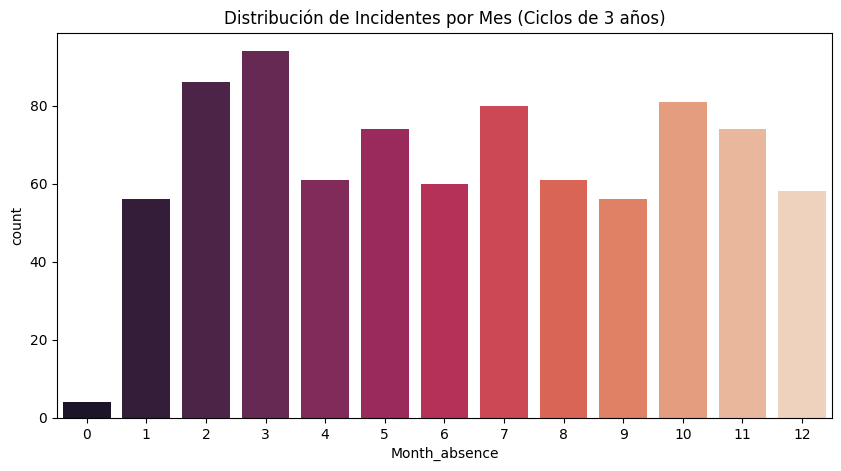

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data=RRHH, x='Month_absence', palette='rocket')
plt.title('Distribución de Incidentes por Mes (Ciclos de 3 años)')
plt.show()

## Este gráfico muestra la distribución de incidentes por mes. Se observa que la mayoría de las ausencias se concentran en el mes de marzo.

### observación para equipo de limpieza: hay el mes 0

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\1849998321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Day_week', y='Absenteeism_hours', palette="rocket")


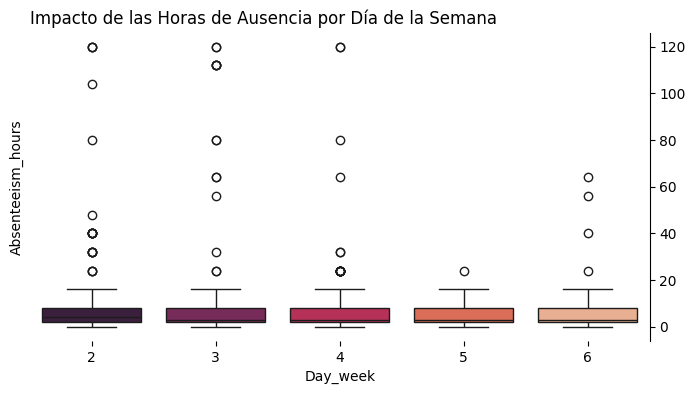

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(data=RRHH, x='Day_week', y='Absenteeism_hours', palette="rocket")
plt.title('Impacto de las Horas de Ausencia por Día de la Semana', loc="left")
sns.despine(right=False, left="False", top='False', bottom="False")
plt.show()

El análisis de este gráfico tipo boxplot revela que, aunque la mayoría de las ausencias en todos los días de la semana son de corta duración (con una mediana cercana a las 3 horas), existe una presencia crítica de valores atípicos (outliers) que distorsionan la operatividad. Se observa que los días 2, 3 y 4 (lunes a miércoles) presentan los casos más extremos, alcanzando picos de hasta 120 horas de ausencia, lo que sugiere incidentes de larga duración o bajas médicas prolongadas que inician a principio de semana. Por el contrario, el día 5 (jueves) muestra la mayor estabilidad con menos valores extremos, mientras que el día 6 (viernes) registra una dispersión moderada, indicando que, aunque hay menos casos de larga duración que el lunes, sigue siendo un punto focal para ausencias que superan la jornada laboral estándar.

# ANÁLISIS DE CAUSALIDAD


C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\2935243177.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=RRHH, x='Reason_absence', order=order, palette="rocket")


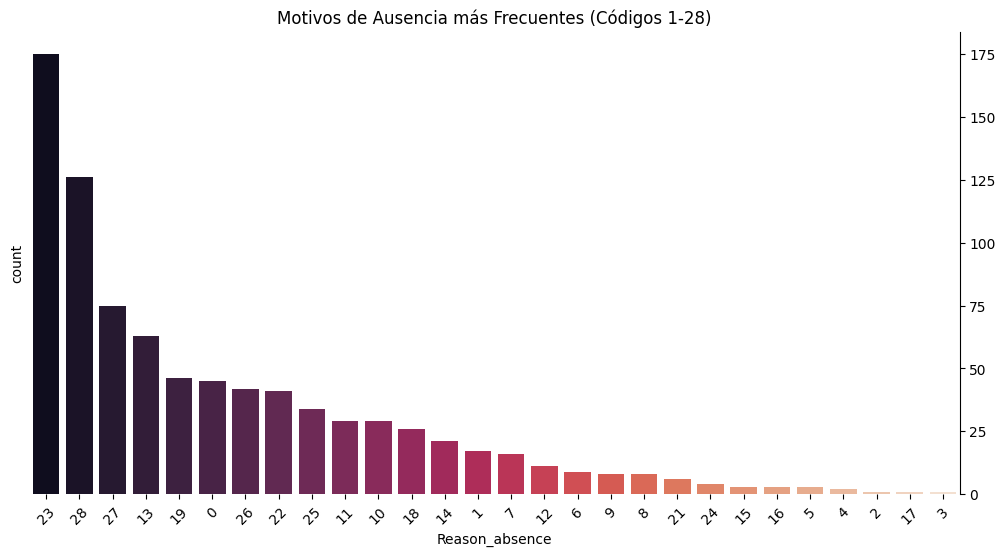

Total de incidentes injustificados: 42


In [27]:
plt.figure(figsize=(12,6))
order = RRHH['Reason_absence'].value_counts().index
sns.countplot(data=RRHH, x='Reason_absence', order=order, palette="rocket")
sns.despine(right=False, left="False", top='False', bottom="False")
plt.title('Motivos de Ausencia más Frecuentes (Códigos 1-28)')
plt.xticks(rotation=45)
plt.show()

unjustified = RRHH[RRHH['Reason_absence'] == 26]
print(f"Total de incidentes injustificados: {len(unjustified)}")

### En este gráfico observamos que la mayoría de las ausencias se deben a visitas médicas (motivo 23), seguidas por consultas odontológicas (motivo 28) y sesiones de fisioterapia (motivo 27). 

# 📊 Clasificación de Enfermedades (CID / ICD)

## 🏥 Categorías con CID

| Código | Categoría                                                                                           |
| ------ | --------------------------------------------------------------------------------------------------- |
| I      | Certain infectious and parasitic diseases                                                           |
| II     | Neoplasms                                                                                           |
| III    | Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism |
| IV     | Endocrine, nutritional and metabolic diseases                                                       |
| V      | Mental and behavioural disorders                                                                    |
| VI     | Diseases of the nervous system                                                                      |
| VII    | Diseases of the eye and adnexa                                                                      |
| VIII   | Diseases of the ear and mastoid process                                                             |
| IX     | Diseases of the circulatory system                                                                  |
| X      | Diseases of the respiratory system                                                                  |
| XI     | Diseases of the digestive system                                                                    |
| XII    | Diseases of the skin and subcutaneous tissue                                                        |
| XIII   | Diseases of the musculoskeletal system and connective tissue                                        |
| XIV    | Diseases of the genitourinary system                                                                |
| XV     | Pregnancy, childbirth and the puerperium                                                            |
| XVI    | Certain conditions originating in the perinatal period                                              |
| XVII   | Congenital malformations, deformations and chromosomal abnormalities                                |
| XVIII  | Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified             |
| XIX    | Injury, poisoning and certain other consequences of external causes                                 |
| XX     | External causes of morbidity and mortality                                                          |
| XXI    | Factors influencing health status and contact with health services                                  |

---

# 📄 Categorías sin CID

Estas categorías **no corresponden a una clasificación CID**, pero son utilizadas para control administrativo en RH:

| Código | Categoría              |
| ------ | ---------------------- |
| 22     | Patient follow-up      |
| 23     | Medical consultation   |
| 24     | Blood donation         |
| 25     | Laboratory examination |
| 26     | Unjustified absence    |
| 27     | Physiotherapy          |
| 28     | Dental consultation    |




### CORRELATION MATRIX

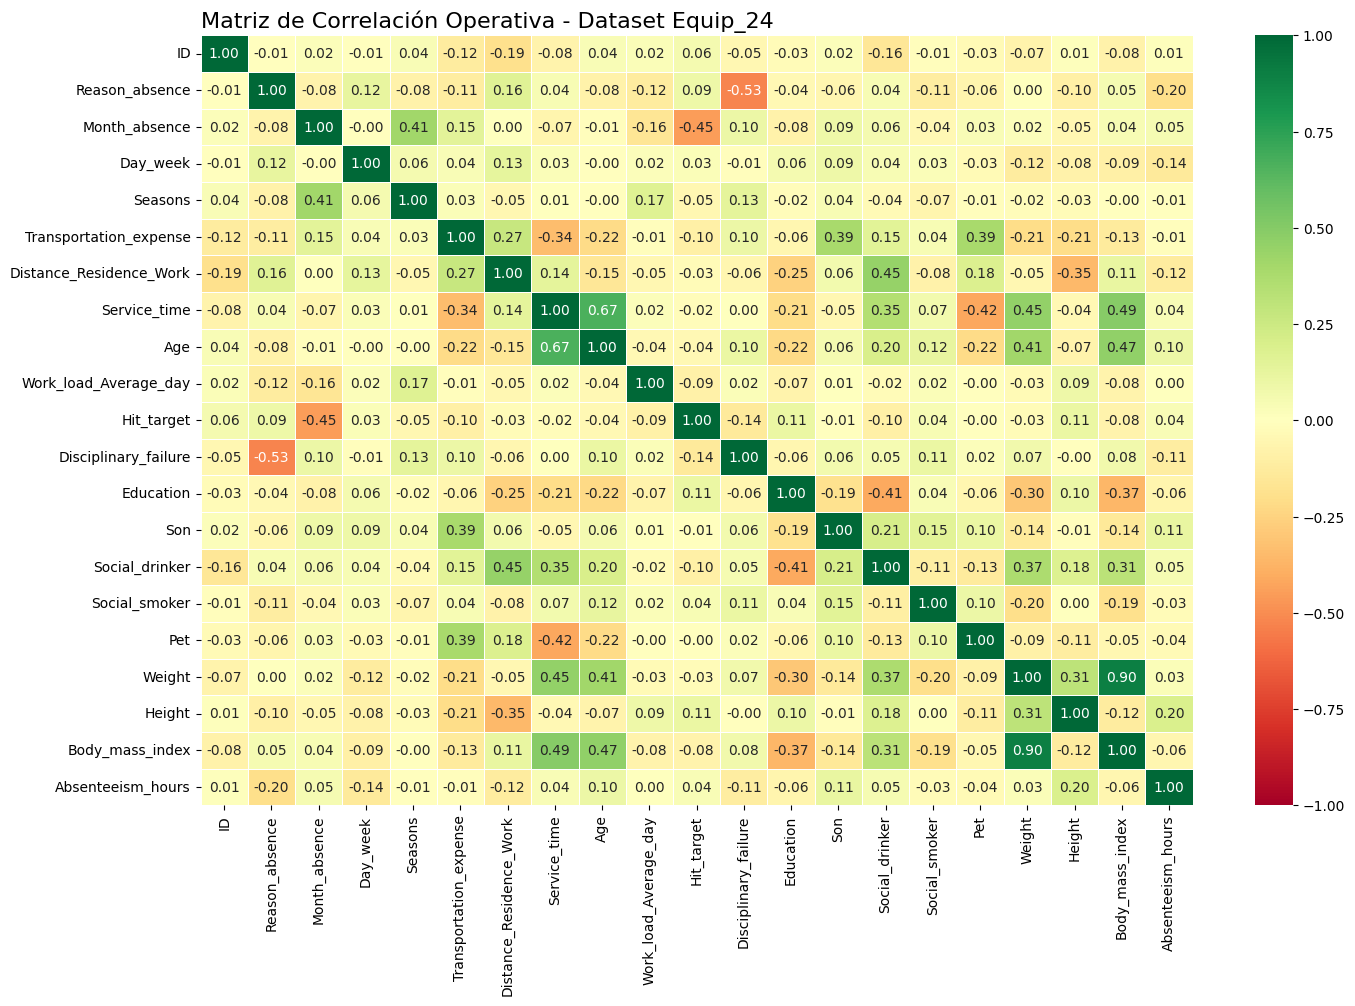

In [28]:
RRHH['Work_load_Average_day'] = RRHH['Work_load_Average_day'].astype(str).str.replace(',', '.').astype(float) # he cambiado para tipo float para sacar el heatmap

cols_to_fix = ['Disciplinary_failure', 'Education', 'Social_drinker', 'Social_smoker', 'Son', 'Pet']
for col in cols_to_fix:
    RRHH[col] = pd.to_numeric(RRHH[col], errors='coerce')


corr = RRHH.select_dtypes(include=[np.number]).corr()


plt.figure(figsize=(16, 10))
sns.heatmap(corr, 
            annot=True,      
            fmt=".2f",      
            cmap='RdYlGn',   
            vmin=-1,        
            vmax=1,          
            center=0,      
            linewidths=.5)   

plt.title('Matriz de Correlación Operativa - Dataset Equip_24', fontsize=16, loc='left')
plt.show()

Existe una correlación superior al 90% entre el Peso (Weight) y el Índice de Masa Corporal (BMI). Dado que el BMI es un indicador calculado directamente a partir del peso y la altura, estas variables presentan una alta redundancia (multicolinealidad). Por lo tanto, resulta estratégicamente viable eliminar las columnas de peso y altura para trabajar exclusivamente con el BMI, simplificando el modelo sin perder información crítica sobre el estado de salud de los empleados.

Se detecta una correlación moderada entre la antigüedad (Service_time) y la edad (Age) de 0.67, lo que es esperable dado que los empleados con mayor experiencia en la empresa tienden a ser de mayor edad. Adicionalmente, ambas variables presentan una correlación positiva con el BMI (0.49 y 0.47 respectivamente), lo que sugiere que el segmento de mayor experiencia puede presentar mayores riesgos de salud asociados.

Se observa una correlación negativa de -0.53 entre Reason_absence y Disciplinary_failure, lo que indica que los empleados con mayor número de faltas disciplinarias tienden a ausentarse por razones distintas a causas médicas justificadas.

La variable Hit_target presenta una correlación negativa de -0.45 con Month_absence, lo que sugiere que en los meses con mayor absentismo el cumplimiento de objetivos tiende a ser menor, evidenciando el impacto directo de las ausencias sobre el rendimiento operativo del equipo.

<Axes: xlabel='Work_load_Average_day', ylabel='Count'>

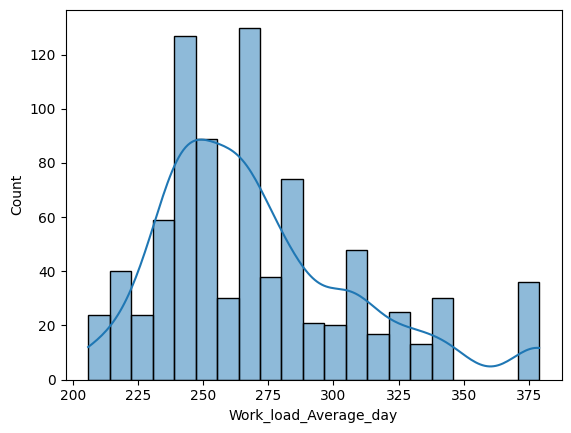

In [29]:
sns.histplot(data=RRHH, x="Work_load_Average_day", kde=True)

<Axes: xlabel='Age', ylabel='Count'>

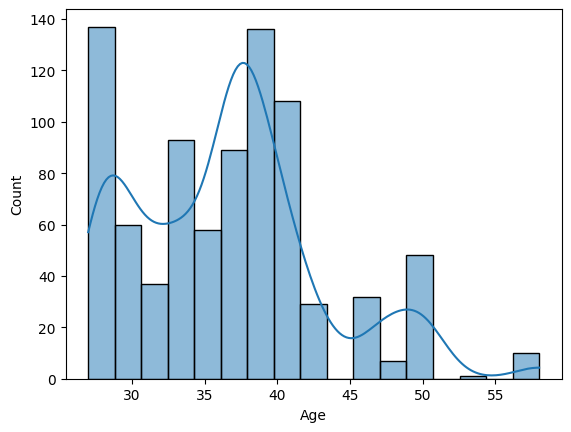

In [30]:
sns.histplot(data=RRHH, x="Age", kde=True)

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\936550153.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Hit_target', y="Month_absence", palette="rocket")


<Axes: xlabel='Hit_target', ylabel='Month_absence'>

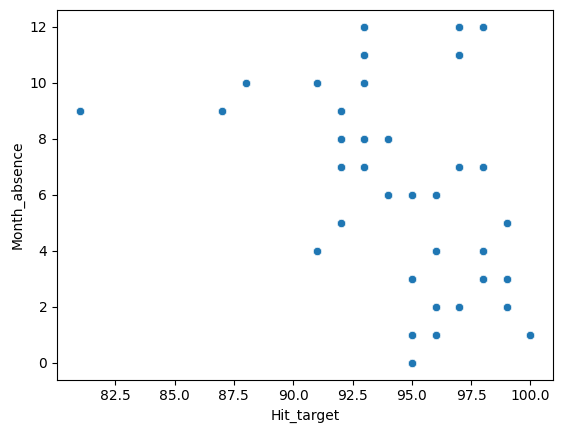

In [31]:
sns.scatterplot(data=RRHH, x='Hit_target', y="Month_absence", palette="rocket")

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\850509939.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Age', y="Service_time", palette="rocket")


<Axes: xlabel='Age', ylabel='Service_time'>

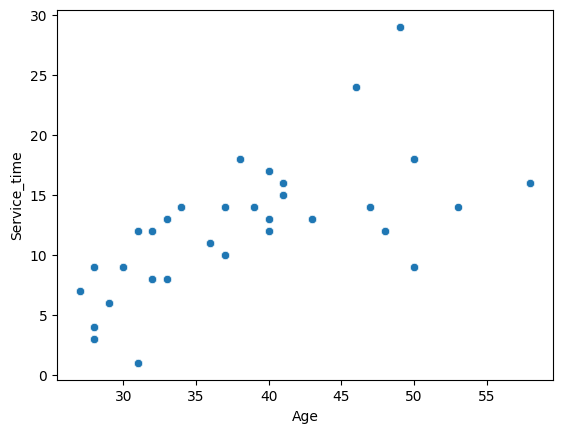

In [32]:
sns.scatterplot(data=RRHH, x='Age', y="Service_time", palette="rocket")

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\1032822318.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=RRHH, x='Body_mass_index', y="Service_time", palette="rocket")


<Axes: xlabel='Body_mass_index', ylabel='Service_time'>

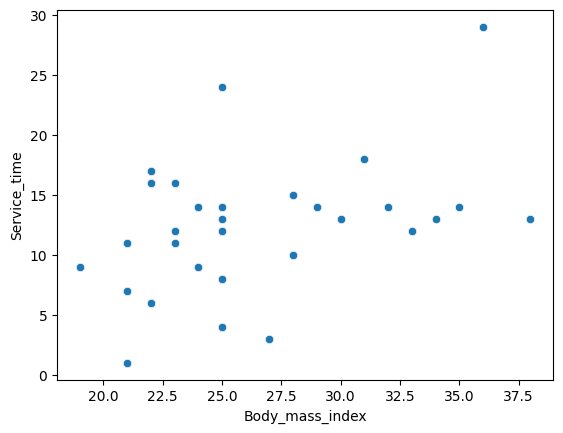

In [33]:
sns.scatterplot(data=RRHH, x='Body_mass_index', y="Service_time", palette="rocket")

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\2381384304.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket")


<Axes: xlabel='Absenteeism_hours'>

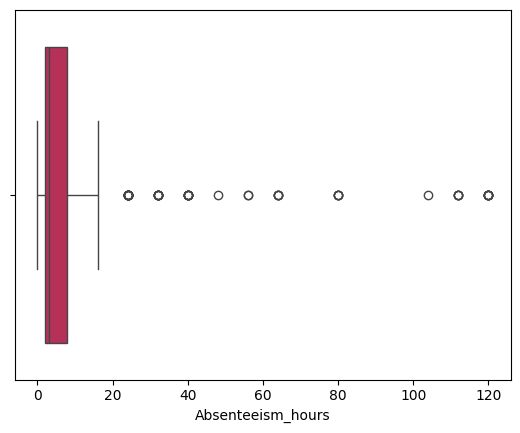

In [34]:
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket")

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\1220868314.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket", showfliers=False)


<Axes: xlabel='Absenteeism_hours'>

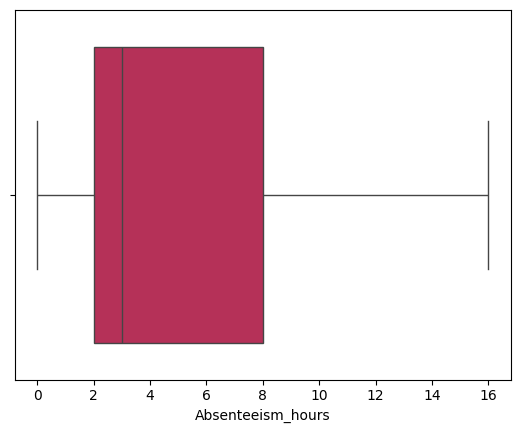

In [35]:
sns.boxplot(data=RRHH, x='Absenteeism_hours', palette="rocket", showfliers=False)

C:\Users\nuez_\AppData\Local\Temp\ipykernel_7892\303400625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x='Body_mass_index', palette="rocket")


<Axes: xlabel='Body_mass_index'>

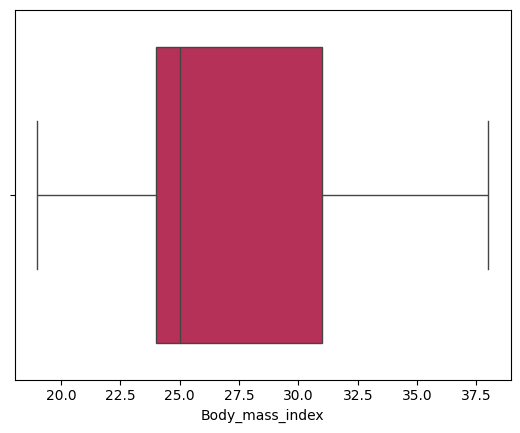

In [36]:
sns.boxplot(data=RRHH, x='Body_mass_index', palette="rocket")

In [37]:
RRHH.sample(5)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
216,13,10,10,6,4,369,17,12,31,284.853,...,0,1,3,1,0,0,70,169,25,8
408,34,28,11,4,4,118,10,10,37,268.519,...,0,1,0,0,0,0,83,172,28,3
301,15,28,9,6,1,291,31,12,40,294.217,...,0,1,1,1,0,1,73,171,25,4
722,23,0,11,6,4,378,49,11,36,284.031,...,1,1,2,0,1,4,65,174,21,0
729,28,0,10,2,4,225,26,9,28,284.853,...,1,1,1,0,0,2,69,169,24,0


In [38]:
RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')